# Federated anomaly detection on IoT traffic

Working with N-BaIoT, real traffic from IoT devices, some of it captured while the
devices were infected with Mirai/BASHLITE botnet malware.

Using the kaggle mirror since it's way easier to pull into colab than dealing with
the UCI zip download.

Picked 4 devices for now: doorbell, thermostat, baby monitor, security camera.


In [1]:
# pulling token from colab secrets, not hardcoding it here

from google.colab import userdata
import os

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(userdata.get("KAGGLE_TOKEN"))
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

!pip install -q kaggle
!kaggle datasets download -d mkashifn/nbaiot-dataset -p /content
!unzip -q -o /content/nbaiot-dataset.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset
License(s): unknown
100% 1.75G/1.75G [00:22<00:00, 85.2MB/s]



turns out this mirror doesn't use the per-device folders like the original UCI
version does. everything's just flat csvs named like 1.benign.csv, 1.gafgyt.combo.csv
etc, number = device id. device_info.csv has the id -> name mapping

In [2]:
# basic setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "/content/data"
pd.read_csv(os.path.join(DATA_DIR, "device_info.csv"))

,DeviceID,DeviceName
0,1,Danmini_Doorbell
1,2,Ecobee_Thermostat
2,3,Ennio_Doorbell
3,4,Philips_B120N10_Baby_Monitor
4,5,Provision_PT_737E_Security_Camera
5,6,Provision_PT_838_Security_Camera
6,7,Samsung_SNH_1011_N_Webcam
7,8,SimpleHome_XCS7_1002_WHT_Security_Camera
8,9,SimpleHome_XCS7_1003_WHT_Security_Camera


In [3]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# just picking 4 devices to keep things manageable for now

DEVICE_IDS = [1, 2, 4, 8]
DEVICE_NAMES = {
    1: "Danmini_Doorbell",
    2: "Ecobee_Thermostat",
    4: "Philips_B120N10_Baby_Monitor",
    8: "SimpleHome_XCS7_1002_WHT_Security_Camera",
}
GAFGYT_ATTACKS = ["combo", "junk", "scan", "tcp", "udp"]
MIRAI_ATTACKS = ["ack", "scan", "syn", "udp", "udpplain"]

## Loading one device to check everything looks right

loading one device first to make sure everything actually works before looping
through all of them

In [5]:
# checking shapes match what device_info said

device_id = 1
benign = pd.read_csv(os.path.join(DATA_DIR, f"{device_id}.benign.csv"))
attack = pd.read_csv(os.path.join(DATA_DIR, f"{device_id}.gafgyt.combo.csv"))

print("benign:", benign.shape)
print("attack (gafgyt combo):", attack.shape)
benign.head()

benign: (49548, 115)
attack (gafgyt combo): (59718, 115)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_radius,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,34.095047,0.0,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,100.081513,0.0,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.000000,0.0,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.000000,0.0,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0


In [6]:
print("missing values, benign:", benign.isnull().sum().sum())
print("missing values, attack:", attack.isnull().sum().sum())

missing values, benign: 0
missing values, attack: 0


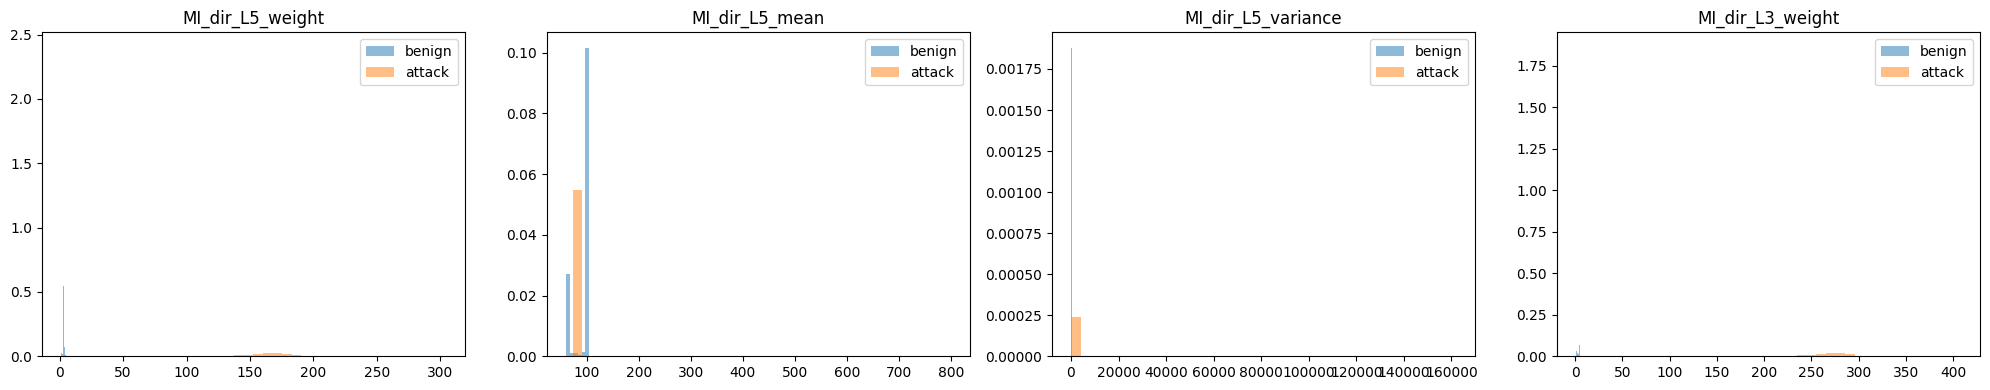

In [7]:
# sanity check: do benign and attack traffic actually look different

features_to_check = benign.columns[:4]

fig, axes = plt.subplots(1, len(features_to_check), figsize=(20, 4))
for ax, feat in zip(axes, features_to_check):
    ax.hist(benign[feat], bins=40, alpha=0.5, label="benign", density=True)
    ax.hist(attack[feat], bins=40, alpha=0.5, label="attack", density=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()


Clear separation between benign and attack traffic on these features, good sign this
is learnable. Now build the full labeled dataset across all 4 devices.

In [8]:
# only grabbing 2 attack files per family for now, don't need all of them

def load_device_data(device_id, attacks_per_family=2):
    name = DEVICE_NAMES[device_id]
    benign_df = pd.read_csv(os.path.join(DATA_DIR, f"{device_id}.benign.csv"))
    benign_df["label"] = 0
    benign_df["attack_type"] = "benign"
    benign_df["device"] = name

    frames = [benign_df]
    for a in GAFGYT_ATTACKS[:attacks_per_family]:
        path = os.path.join(DATA_DIR, f"{device_id}.gafgyt.{a}.csv")
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["label"] = 1
            df["attack_type"] = f"gafgyt_{a}"
            df["device"] = name
            frames.append(df)
    for a in MIRAI_ATTACKS[:attacks_per_family]:
        path = os.path.join(DATA_DIR, f"{device_id}.mirai.{a}.csv")
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["label"] = 1
            df["attack_type"] = f"mirai_{a}"
            df["device"] = name
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

all_devices_df = pd.concat([load_device_data(d) for d in DEVICE_IDS], ignore_index=True)
print(all_devices_df.shape)
all_devices_df["label"].value_counts()

(1344470, 118)


,count
label,
1,1059984
0,284486


attack rows way outnumber benign here, more than 3:1. that's just because the
attack captures happened to be longer, not realistic for an actual deployment.
doesn't matter for training since the models only ever see benign data anyway,
but worth mentioning in the readme

In [9]:
# saving so notebook 2 can just load this instead of rebuilding it

os.makedirs("/content/drive/MyDrive/gri-project1/processed", exist_ok=True)
all_devices_df.to_csv("/content/drive/MyDrive/gri-project1/processed/combined_labeled.csv", index=False)
print("saved")

saved


Next up: `02_baseline_centralized.ipynb`, actually training something on this